# RL Fine-Tuning with Unsloth on AEGIS-Env

**Efficient RL Training for Automated Grading with Small Language Models**

This notebook demonstrates how to fine-tune a small language model (SLM) using **GRPO** (Group Relative Policy Optimization) with **Unsloth** for memory-efficient training on the **AEGIS-Env** grading environment.

### Workflow:
1. ✅ Install dependencies (Unsloth, transformers, TRL, etc.)
2. ✅ Set up the Unsloth environment for GPU acceleration
3. ✅ Configure RL hyperparameters
4. ✅ Load a pre-trained model with LoRA fine-tuning
5. ✅ Define multi-component reward functions
6. ✅ Run the GRPO training loop with curriculum learning
7. ✅ Monitor metrics and learning curves
8. ✅ Save and export the trained model

**Environment**: Google Colab (GPU recommended: T4 or A100)  
**Dataset**: AEGIS-Env with 3 difficulty tiers (easy → medium → hard)

## 1. Install and Import Dependencies

Install all required packages for RL training with Unsloth on AEGIS-Env.

In [1]:
%%capture
import os, importlib.util
!pip install --upgrade -qqq uv
if importlib.util.find_spec("torch") is None or "COLAB_" in "".join(os.environ.keys()):
    try: import numpy; get_numpy = f"numpy=={numpy.__version__}"
    except: get_numpy = "numpy"
    !uv pip install -qqq \
        "torch>=2.8.0" "triton>=3.4.0" {get_numpy} torchvision bitsandbytes "transformers==4.56.2" trackio \
        "unsloth_zoo[base] @ git+https://github.com/unslothai/unsloth-zoo" \
        "unsloth[base] @ git+https://github.com/unslothai/unsloth" \
        git+https://github.com/triton-lang/triton.git@0add68262ab0a2e33b84524346cb27cbb2787356#subdirectory=python/triton_kernels
elif importlib.util.find_spec("unsloth") is None:
    !uv pip install -qqq unsloth trackio
!uv pip install --upgrade --no-deps transformers==4.56.2 "tokenizers>=0.22.0,<=0.23.0" trl==0.29.1 unsloth unsloth_zoo

# Install OpenEnv and related packages

In [2]:
%%capture
!pip install -qqq fastapi uvicorn requests open_spiel --prefer-binary
!pip install "openenv-core[core]>=0.2.1"
!git clone https://github.com/meta-pytorch/OpenEnv.git > /dev/null 2>&1
%cd OpenEnv
import subprocess, sys, os
from pathlib import Path
sys.path.insert(0, './envs')  # Add OpenEnv envs for textarena_env module
sys.path.insert(0, './src')
working_directory = str(Path.cwd().absolute())

In [3]:
!uv pip install -qqq openai pydantic datasets

In [6]:
import os
# AEGIS-Env code (client + prompts). Override with your Git repo URL if preferred.
AEGIS_REPO = os.environ.get(
    "AEGIS_CODE_CLONE_URL",
    "https://huggingface.co/spaces/NishithP2004/aegis-env",
)
!rm -rf /content/aegis-env-space && git clone --depth 1 {AEGIS_REPO} /content/aegis-env-space

import sys
sys.path.insert(0, "/content/aegis-env-space")

Cloning into '/content/aegis-env-space'...
remote: Enumerating objects: 34, done.
remote: Counting objects: 100% (34/34), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 34 (delta 3), reused 21 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (34/34), 301.29 KiB | 4.43 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [ ]:
# Core imports
from unsloth import FastLanguageModel
import asyncio
import json
import logging
import os
import sys
import random
from pathlib import Path
from typing import Any, Dict, List, Optional

# Set up logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# ML/RL imports
import torch
import numpy as np
from datasets import Dataset
from transformers import TextStreamer
from trl import GRPOConfig, GRPOTrainer

# OpenEnv imports
from client import AegisEnv
from models import AegisAction, AegisObservation
from inference import build_user_prompt, _parse_action, _strip_markdown_json_fence

# Async support
import nest_asyncio
nest_asyncio.apply()

print("✅ All imports successful!")
print(f"🔥 CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"🎮 GPU: {torch.cuda.get_device_name(0)}")
    print(f"📊 GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

✅ All imports successful!
🔥 CUDA Available: True
🎮 GPU: Tesla T4
📊 GPU Memory: 15.64 GB


## 2. Set Up Unsloth Environment

Configure Unsloth for optimal training performance, device selection, and model loading.

In [8]:
# Configuration for Unsloth
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MAX_SEQ_LENGTH = 4096
LORA_RANK = 8

logger.info(f"🎯 Device: {DEVICE}")
logger.info(f"📐 Max Sequence Length: {MAX_SEQ_LENGTH}")
logger.info(f"🎛️  LoRA Rank: {LORA_RANK}")

# Environment configuration
AEGIS_OPENENV_BASE = os.environ.get(
    "AEGIS_OPENENV_BASE",
    "https://nishithp2004-aegis-env.hf.space/"
)

MODEL_NAME = os.environ.get(
    "MODEL_NAME",
    "unsloth/Llama-3.2-3B-Instruct-bnb-4bit"
)

logger.info(f"🌐 OpenEnv Base: {AEGIS_OPENENV_BASE}")
logger.info(f"🤖 Model: {MODEL_NAME}")

## 3. Initialize RL Training Configuration

Define hyperparameters for GRPO training including learning rate, batch size, and training episodes.

In [ ]:
# RL Training Hyperparameters
TRAINING_CONFIG = {
    # Learning dynamics
    "learning_rate": 2e-4,
    "weight_decay": 0.001,
    "warmup_ratio": 0.1,
    "lr_scheduler_type": "linear",

    # Batch and gradient configuration
    "per_device_train_batch_size": 1,
    "gradient_accumulation_steps": 2,

    # GRPO-specific
    "temperature": 0.8,
    "num_generations": 2,

    # Training duration
    "num_train_epochs": 1,  # Train through entire dataset 1 times
    "save_strategy": "epoch",  # Save checkpoint after each epoch

    # Model sequence limits
    "max_prompt_length": 2048,
    "max_completion_length": 1024,
}

# Dataset configuration
DATASET_CONFIG = {
    "seeds": {
        "easy": 1000,
        "medium": 11000,
        "hard": 21000,
    },
    "tiers": ["easy", "medium", "hard"],
}

logger.info("✅ Training Configuration:")
for key, value in TRAINING_CONFIG.items():
    logger.info(f"   {key}: {value}")

## 4. Load Pre-trained Model with Unsloth

Load a small language model with LoRA fine-tuning for efficient training.

In [10]:
logger.info(f"📥 Loading model: {MODEL_NAME}")

# Load model with Unsloth
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    load_in_4bit=True,
    max_seq_length=MAX_SEQ_LENGTH,
)

logger.info("✅ Model loaded successfully")

# Apply LoRA for efficient fine-tuning
logger.info(f"🎛️  Applying LoRA (rank={LORA_RANK})...")
model = FastLanguageModel.get_peft_model(
    model,
    r=LORA_RANK,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
    lora_alpha=LORA_RANK * 2,
    use_gradient_checkpointing="unsloth",
    random_state=3407,
)

logger.info("✅ LoRA applied successfully")
logger.info(f"🤖 Model size: {sum(p.numel() for p in model.parameters()) / 1e6:.2f}M parameters")

==((====))==  Unsloth 2026.5.2: Fast Llama patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

Unsloth 2026.5.2 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


## 5. Build Training Dataset with Curriculum Learning

Fetch training examples from AEGIS-Env across all difficulty tiers with curriculum progression.

In [ ]:
# Helper functions for multi-step interactive rollouts
def _run_async(coro):
    """Run async coroutine in synchronous context."""
    try:
        loop = asyncio.get_event_loop()
    except RuntimeError:
        loop = asyncio.new_event_loop()
        asyncio.set_event_loop(loop)
    return loop.run_until_complete(coro)


async def run_interactive_episode(
    env: AegisEnv,
    model,
    tokenizer,
    question_data: Dict[str, Any],
    max_steps: int = 10,
) -> tuple[float, List[Dict[str, Any]]]:
    """🎯 Run a full interactive episode through the AEGIS pipeline.

    The model navigates dynamically from arbiter → scrutinizer → validator → mentor,
    making its own decisions at each stage. No hardcoded actions.

    Args:
        env: AegisEnv instance (connected and ready)
        model: Fine-tuned language model
        tokenizer: Tokenizer for the model
        question_data: Dict with 'seed' (int), 'task_name' (str)
        max_steps: Maximum steps to prevent infinite loops

    Returns:
        (cumulative_episode_reward, episode_trajectory)
        - cumulative_episode_reward: float in [0, 1] (unscaled from flow bank)
        - episode_trajectory: List of dicts with stage, action, reward, obs
    """
    episode_trajectory = []
    cumulative_reward = 0.0
    step_count = 0
    done = False

    try:
        # Initialize: Reset the environment
        seed = int(question_data.get("seed", 0))
        task_name = str(question_data.get("task_name", "easy"))

        reset_result = await env.reset(seed=seed, task_name=task_name)
        obs = reset_result.observation

        logger.debug(f"🎬 Episode initialized: seed={seed}, task={task_name}, stage={obs.current_stage}")

        # Loop through all stages until mentor completes
        while not done and step_count < max_steps:
            current_stage = str(getattr(obs, "current_stage", "unknown") or "unknown")

            # Build stage-specific prompt
            user_prompt = build_user_prompt(
                step=step_count,
                last_action=None,  # For now; could track previous action
                last_reward=0.0,  # For now; could track cumulative reward
                history=[],
                obs=obs,
            )

            logger.debug(f"  Step {step_count}: {current_stage} stage")

            # Generate action using the model
            try:
                messages = [{"role": "user", "content": user_prompt}]
                inputs = tokenizer.apply_chat_template(
                    messages, tokenize=False, add_generation_prompt=True
                )

                # Tokenize input
                input_ids = tokenizer(inputs, return_tensors="pt").to(model.device)

                # Generate with temperature sampling (not greedy)
                with torch.no_grad():
                    outputs = model.generate(
                        input_ids["input_ids"],
                        attention_mask=input_ids.get("attention_mask"),
                        max_new_tokens=512,
                        temperature=0.7,
                        top_p=0.9,
                        do_sample=True,
                        pad_token_id=tokenizer.eos_token_id,
                    )

                generated_text = tokenizer.decode(
                    outputs[0][input_ids["input_ids"].shape[1]:],
                    skip_special_tokens=True
                )

                # Parse action from model output
                max_score = float(obs.max_score or 1.0)
                action = _parse_action(
                    _strip_markdown_json_fence(generated_text),
                    max_score
                )

                logger.debug(f"    Generated action: score={action.proposed_score}, decision={action.routing_decision}")

            except Exception as e:
                logger.warning(f"    ⚠️ Failed to parse action: {e}. Skipping step.")
                action = AegisAction(
                    proposed_score=0.5,
                    agent_reasoning="Failed to generate valid action",
                    routing_decision="proceed",
                )

            # Execute action in environment
            step_result = await env.step(action)
            next_obs = step_result.observation
            step_reward = float(step_result.reward if step_result.reward is not None else 0.0)
            done = bool(step_result.done if hasattr(step_result, 'done') else next_obs.current_stage == "finished")

            cumulative_reward += step_reward
            step_count += 1

            # Record trajectory
            episode_trajectory.append({
                "step": step_count,
                "stage": current_stage,
                "action": {
                    "proposed_score": float(action.proposed_score),
                    "agent_reasoning": str(action.agent_reasoning),
                    "routing_decision": str(action.routing_decision),
                },
                "reward": step_reward,
                "next_stage": str(getattr(next_obs, "current_stage", "unknown") or "unknown"),
            })

            obs = next_obs

        logger.debug(f"✅ Episode complete: {step_count} steps, cumulative_reward={cumulative_reward:.4f}")

    except Exception as e:
        logger.error(f"❌ Episode failed: {e}")
        cumulative_reward = 0.0

    # Ensure reward is clipped to [0, 1]
    cumulative_reward = max(0.0, min(1.0, cumulative_reward))

    return cumulative_reward, episode_trajectory


# Helper functions for efficient dataset loading
def _unwrap_object_id(v: Any) -> str:
    """Extract string ID from MongoDB ObjectId dict."""
    if isinstance(v, dict) and "$oid" in v:
        return str(v.get("$oid") or "")
    return str(v or "")


def _unwrap_number(v: Any) -> Optional[float]:
    """Extract float from MongoDB NumberDouble dict."""
    if v is None:
        return None
    if isinstance(v, (int, float)):
        return float(v)
    if isinstance(v, dict) and "$numberDouble" in v:
        s = str(v.get("$numberDouble"))
        if s == "Infinity":
            return float("inf")
        if s == "-Infinity":
            return float("-inf")
        if s == "NaN":
            return float("nan")
    try:
        return float(v)
    except Exception:
        return None


def _reference_feedback_from_record(rec: Dict[str, Any]) -> str:
    """Extract reference feedback from record."""
    feedback = rec.get("feedback")
    if feedback is not None:
        return str(feedback).strip()
    ev = rec.get("evaluation") or {}
    agent_feedback = (ev.get("agent_feedback") or {}) if isinstance(ev, dict) else {}
    if isinstance(agent_feedback, dict):
        ia = agent_feedback.get("improvement_advice")
        if ia is not None:
            return str(ia).strip()
    return str(rec.get("reference_feedback") or "")


def _load_full_dataset_json() -> List[Dict[str, Any]]:
    """Load the full dataset from cached JSON (same logic as aegis_env_environment.py)."""
    from pathlib import Path
    
    repo_id = os.environ.get("AEGIS_HF_DATASET_REPO") or "NishithP2004/AEGIS"
    filename = os.environ.get("AEGIS_HF_DATASET_FILE") or "train.json"
    
    # Try to find cached dataset
    cache_dir = Path.home() / ".cache" / "huggingface" / "datasets"
    
    # Download if not cached
    try:
        from huggingface_hub import hf_hub_download
        dataset_path = hf_hub_download(
            repo_id=repo_id,
            filename=filename,
            repo_type="dataset",
            cache_dir=str(cache_dir.parent),
        )
    except Exception as e:
        logger.warning(f"Failed to download dataset: {e}")
        return []
    
    # Parse JSON
    try:
        with open(dataset_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
    except Exception as e:
        logger.error(f"Failed to load dataset JSON: {e}")
        return []
    
    # Extract records
    if isinstance(data, dict) and "data" in data and isinstance(data["data"], list):
        records = data["data"]
    elif isinstance(data, list):
        records = data
    else:
        logger.error("Unexpected dataset JSON structure")
        return []
    
    # Normalize records (unwrap MongoDB types)
    normalized = []
    for rec in records:
        if not isinstance(rec, dict):
            continue
        norm = dict(rec)
        norm["_id"] = _unwrap_object_id(rec.get("_id"))
        for k in ("max_score", "min_score", "obtained_score"):
            norm[k] = _unwrap_number(rec.get(k))
        normalized.append(norm)
    
    return normalized


def _apply_train_test_split(records: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    """Apply train/test split with balanced sampling (same logic as aegis_env_environment.py).
    
    Test split ratios: ricechem=10%, asap-sas=20%, mohler=30%.
    Returns only the training subset.
    """
    SEED = 42
    train_seed = random.Random(SEED)
    
    splits = {
        "ricechem": 0.10,
        "asap-sas": 0.20,
        "mohler": 0.30,
    }
    
    test_indices = set()
    
    for dataset, ratio in splits.items():
        # Filter records for this dataset
        dataset_indices = [i for i, rec in enumerate(records) if rec.get("dataset") == dataset]
        if not dataset_indices:
            continue
        
        # Group by question
        question_groups: Dict[str, List[int]] = {}
        for idx in dataset_indices:
            question = records[idx].get("question", "")
            if question not in question_groups:
                question_groups[question] = []
            question_groups[question].append(idx)
        
        # Calculate how many samples per question
        total_rows = len(dataset_indices)
        test_size = int(total_rows * ratio)
        num_questions = len(question_groups)
        per_question = max(1, int(test_size / num_questions))
        
        # Sample from each question to balance the test set
        for question, indices in question_groups.items():
            sample_size = min(per_question, len(indices))
            sampled_indices = train_seed.sample(indices, k=sample_size)
            test_indices.update(sampled_indices)
    
    # Return only training records (excluding test indices)
    train_records = [rec for i, rec in enumerate(records) if i not in test_indices]
    return train_records


def _build_prompt_from_record(rec: Dict[str, Any]) -> str:
    """Build a prompt string from a dataset record (arbiter stage)."""
    question = str(rec.get("question") or "")
    student_answer = str(rec.get("student_response") or rec.get("student_answer") or "")
    rubric = str(rec.get("rubrics") or "")
    max_score = float(rec.get("max_score") or 1.0)
    
    # Build a basic prompt (normally would use build_user_prompt from inference.py)
    prompt_text = f"""Question: {question}

Student Response: {student_answer}

Rubric: {rubric}

Max Score: {max_score}

Please provide your grading assessment."""
    
    return prompt_text.strip()


def build_dataset_from_json(base_url: str = None) -> tuple[Dataset, Dict[str, int]]:
    """Build training dataset directly from cached JSON with train-test split.
    
    Returns: (train_dataset, tier_stats)
    - train_dataset: Hugging Face Dataset with curriculum order
    - tier_stats: Dict with count of samples per tier
    """
    logger.info("📊 Loading full dataset from cache...")
    
    # Load full dataset
    all_records = _load_full_dataset_json()
    if not all_records:
        raise RuntimeError("Failed to load dataset")
    logger.info(f"✅ Loaded {len(all_records)} total records from JSON")
    
    # Apply train-test split (SEED=42)
    logger.info("🔄 Applying train-test split (ricechem=10%, asap-sas=20%, mohler=30%)...")
    train_records = _apply_train_test_split(all_records)
    logger.info(f"✅ Split complete: {len(train_records)} training records")
    
    # Map datasets to curriculum tiers and build examples
    dataset_to_tier = {
        "mohler": "easy",
        "asap-sas": "medium",
        "ricechem": "hard",
    }
    
    rows: List[Dict] = []
    tier_stats = {"easy": 0, "medium": 0, "hard": 0}
    
    logger.info("🏗️  Building training examples with curriculum order...")
    
    # Process in dataset order (already sorted by curriculum: mohler → asap-sas → ricechem)
    for rec in train_records:
        dataset = str(rec.get("dataset") or "")
        tier = dataset_to_tier.get(dataset)
        
        if not tier:
            continue
        
        # Build prompt
        try:
            prompt_text = _build_prompt_from_record(rec)
        except Exception as e:
            logger.debug(f"Failed to build prompt: {e}")
            continue
        
        # Create training example
        example = {
            "prompt": [{"role": "user", "content": prompt_text}],
            "answer": 0,  # Placeholder for dataset structure
            "task_name": tier,
            "dataset": dataset,
            "episode_seed": hash(rec.get("_id", "")) % 1000000,  # Pseudo-seed for determinism
            "max_score": float(rec.get("max_score") or 10.0),
            "question": rec.get("question", ""),
            "student_response": str(rec.get("student_response") or rec.get("student_answer") or ""),
            "rubrics": str(rec.get("rubrics") or "")
        }
        
        rows.append(example)
        tier_stats[tier] += 1
    
    logger.info(f"✅ Built {len(rows)} training examples")
    logger.info(f"   Easy tier (mohler): {tier_stats['easy']} samples")
    logger.info(f"   Medium tier (asap-sas): {tier_stats['medium']} samples")
    logger.info(f"   Hard tier (ricechem): {tier_stats['hard']} samples")
    
    # Create dataset
    train_ds = Dataset.from_list(rows)
    return train_ds, tier_stats


# Build the dataset (fast, direct from JSON cache)
logger.info("🚀 Building training dataset from cached JSON...")
train_ds, tier_stats = build_dataset_from_json()
logger.info(f"📈 Dataset ready: {len(train_ds)} examples in curriculum order")

## 6. Define Multi-Component Reward Functions

Create reward functions for GRPO training: format validation, output quality, and environment rewards.

In [ ]:
async def evaluate_interactive_episode(
    model,
    tokenizer,
    seed: int,
    task_name: str,
    max_score: float,
    base_url: str,
) -> float:
    """🏆 Evaluate a full interactive episode in the environment.
    
    The model navigates all 4 stages (arbiter → scrutinizer → validator → mentor)
    dynamically, and we collect the cumulative flow-bank reward.
    
    Returns: Cumulative episode reward in [0.0, 1.0] (UNSCALED from flow bank)
    """
    env = AegisEnv(base_url=base_url)
    await env.connect()
    try:
        question_data = {
            "seed": seed,
            "task_name": task_name,
        }
        cumulative_reward, trajectory = await run_interactive_episode(
            env=env,
            model=model,
            tokenizer=tokenizer,
            question_data=question_data,
            max_steps=10,
        )
        
        logger.debug(f"Episode reward: {cumulative_reward:.4f}, steps: {len(trajectory)}")
        return cumulative_reward
        
    except Exception as e:
        logger.debug(f"Episode evaluation error: {e}")
        return 0.0  # Zero reward on error
    finally:
        await env.close()


def grpo_reward_fn(
    prompts,
    completions,
    episode_seed,
    task_name,
    max_score,
    base_url: str,
    **kwargs,
) -> List[float]:
    """🌟 GRPO reward function: Full multi-step interactive rollouts (no hardcoding).
    
    This is the single source of truth for reward computation.
    - Each sample generates predictions at all 4 pipeline stages dynamically
    - No scaling: returns [0, 1] flow bank rewards directly
    - GRPO baseline centering handles negative/positive signal naturally
    
    Args:
        prompts: Chat prompt list
        completions: Model completions (not used; we run full episodes)
        episode_seed: Seeds for environment resets
        task_name: Difficulty tiers
        max_score: Maximum scores for grading
        base_url: AEGIS-Env base URL
    
    Returns:
        List of episode rewards in [0.0, 1.0]
    """
    scores = []
    
    for seed, task, ms in zip(episode_seed, task_name, max_score):
        try:
            # Run full interactive episode (no reliance on model completions)
            coro = evaluate_interactive_episode(
                model=model,
                tokenizer=tokenizer,
                seed=int(seed),
                task_name=str(task),
                max_score=float(ms),
                base_url=base_url,
            )
            
            # Execute async in sync context
            reward = float(_run_async(coro))
            
            # Ensure reward is in valid [0, 1] range
            reward = max(0.0, min(1.0, reward))
            scores.append(reward)
            
            logger.debug(f"Seed {seed} ({task}): reward={reward:.4f}")
            
        except Exception as e:
            logger.debug(f"Reward evaluation failed for seed {seed}: {e}")
            scores.append(0.0)  # Zero reward on error
    
    logger.info(f"Batch rewards (n={len(scores)}, unscaled): mean={np.mean(scores):.4f}, " +
                f"min={np.min(scores):.4f}, max={np.max(scores):.4f}")
    return scores


logger.info("✅ Reward function defined:")
logger.info("   • grpo_reward_fn: Full multi-step interactive rollouts")
logger.info("   • Returns unscaled [0, 1] flow bank rewards (no scaling)")
logger.info("   • Model navigates all 4 pipeline stages dynamically")

## 7. Configure and Initialize GRPO Trainer

Set up GRPO training configuration and initialize the trainer with all components.

In [ ]:
# Compute prompt length
sample_prompt = train_ds[0]["prompt"]
sample_text = tokenizer.apply_chat_template(
    sample_prompt, tokenize=False, add_generation_prompt=True
)
max_prompt_length = len(tokenizer.encode(sample_text))
logger.info(f"📏 Sample prompt length: {max_prompt_length} tokens")

# Adjust sequence lengths
max_seq_length = MAX_SEQ_LENGTH
max_prompt_length = min(max_prompt_length + 8, max_seq_length // 2)
max_completion_length = min(
    TRAINING_CONFIG["max_completion_length"],
    max_seq_length - max_prompt_length
)

logger.info(f"📐 Max prompt length: {max_prompt_length} tokens")
logger.info(f"📐 Max completion length: {max_completion_length} tokens")

# Configure GRPO training
training_args = GRPOConfig(
    # Learning dynamics
    temperature=TRAINING_CONFIG["temperature"],
    learning_rate=TRAINING_CONFIG["learning_rate"],
    weight_decay=TRAINING_CONFIG["weight_decay"],
    warmup_ratio=TRAINING_CONFIG["warmup_ratio"],
    lr_scheduler_type=TRAINING_CONFIG["lr_scheduler_type"],
    optim="adamw_8bit",

    # Logging and saving
    logging_steps=1,
    per_device_train_batch_size=TRAINING_CONFIG["per_device_train_batch_size"],
    gradient_accumulation_steps=TRAINING_CONFIG["gradient_accumulation_steps"],

    # GRPO specifics
    num_generations=TRAINING_CONFIG["num_generations"],

    # Training duration - using curriculum: 3 epochs easy, 2 medium, 1 hard
    num_train_epochs=TRAINING_CONFIG['num_train_epochs'],
    save_strategy=TRAINING_CONFIG['save_strategy'],
    save_total_limit=5,

    # Output
    output_dir="outputs_grpo_aegis",
    logging_dir="outputs_grpo_aegis/logs",

    # Mixed precision
    bf16=torch.cuda.is_available() and torch.cuda.get_device_capability()[0] >= 8,
    fp16=torch.cuda.is_available() and torch.cuda.get_device_capability()[0] < 8,
)

# Wrap grpo_reward_fn with base_url
def grpo_reward_fn_with_url(prompts, completions, episode_seed, task_name, max_score, **kwargs):
    return grpo_reward_fn(
        prompts,
        completions,
        episode_seed,
        task_name,
        max_score,
        base_url=AEGIS_OPENENV_BASE,
        **kwargs,
    )

# Initialize GRPO trainer
logger.info("🎯 Initializing GRPO Trainer with multi-step interactive rollouts...")
trainer = GRPOTrainer(
    model=model,
    processing_class=tokenizer,
    reward_funcs=[grpo_reward_fn_with_url],
    args=training_args,
    train_dataset=train_ds,
    max_prompt_length=max_prompt_length,
    max_completion_length=max_completion_length,
)

logger.info("✅ Trainer initialized and ready for training!")

## 8. Run GRPO Training Loop

Execute the main training loop with curriculum learning from easy to hard tasks.

In [ ]:
logger.info("=" * 80)
logger.info("🚀 STARTING CURRICULUM GRPO TRAINING")
logger.info("=" * 80)
logger.info(f"Total samples: {len(train_ds)}")
logger.info(f"  - Easy tier (mohler): {tier_stats['easy']} samples")
logger.info(f"  - Medium tier (asap-sas): {tier_stats['medium']} samples")
logger.info(f"  - Hard tier (ricechem): {tier_stats['hard']} samples")
logger.info(f"Reward function: grpo_reward_fn (multi-step interactive rollouts, [0,1] unscaled)")
logger.info("=" * 80)

# ===== Curriculum Learning Configuration =====
# Automatically detect tier boundaries by scanning task_name field
tier_boundaries = {}
current_tier = None

for idx, sample in enumerate(train_ds):
    task_name = sample.get("task_name", "easy")
    if task_name != current_tier:
        if task_name not in tier_boundaries:
            tier_boundaries[task_name] = idx
        current_tier = task_name

tier_boundaries["_end"] = len(train_ds)

# Build curriculum phases dynamically based on actual dataset
curriculum_phases = []

for tier_name in DATASET_CONFIG["tiers"]:
    if tier_name in tier_boundaries:
        start_idx = tier_boundaries[tier_name]
        # Find the end index (start of next tier or end of dataset)
        next_tier_idx = None
        for next_tier in DATASET_CONFIG["tiers"][DATASET_CONFIG["tiers"].index(tier_name) + 1:]:
            if next_tier in tier_boundaries:
                next_tier_idx = tier_boundaries[next_tier]
                break
        
        if next_tier_idx is None:
            next_tier_idx = tier_boundaries.get("_end", len(train_ds))
        
        if start_idx < next_tier_idx:
            # Epochs distribution: easy=3, medium=2, hard=1
            num_epochs = {"easy": 3, "medium": 2, "hard": 1}.get(tier_name, 1)
            curriculum_phases.append({
                "tier_name": tier_name,
                "sample_range": (start_idx, next_tier_idx),
                "num_epochs": num_epochs,
            })

logger.info("\n📚 Curriculum Learning Plan:")
for phase in curriculum_phases:
    start, end = phase["sample_range"]
    logger.info(f"  Phase: {phase['tier_name'].upper()}")
    logger.info(f"    Samples: {start}-{end-1} (n={end-start})")
    logger.info(f"    Epochs: {phase['num_epochs']}")

# ===== Execute Curriculum Training =====
total_epochs = 0
for phase_idx, phase in enumerate(curriculum_phases):
    tier_name = phase["tier_name"]
    sample_start, sample_end = phase["sample_range"]
    num_epochs = phase["num_epochs"]
    
    logger.info(f"\n{'='*80}")
    logger.info(f"PHASE {phase_idx + 1}/{len(curriculum_phases)}: {tier_name.upper()} TIER")
    logger.info(f"{'='*80}")
    logger.info(f"Samples: {sample_start}-{sample_end-1} (n={sample_end - sample_start})")
    logger.info(f"Epochs: {num_epochs}")
    
    # Create subset dataset for this curriculum phase
    tier_dataset = train_ds.select(range(sample_start, sample_end))
    logger.info(f"✅ Created curriculum dataset: {len(tier_dataset)} samples")
    
    # Update trainer dataset and epoch count
    trainer.train_dataset = tier_dataset
    trainer.args.num_train_epochs = num_epochs
    
    logger.info(f"🎓 Training {tier_name} tier ({num_epochs} epoch(s))...")
    
    # Run training
    try:
        train_result = trainer.train()
        logger.info(f"✅ {tier_name.upper()} phase complete")
        logger.info(f"   Loss: {train_result.training_loss:.4f}")
    except Exception as e:
        logger.error(f"❌ {tier_name.upper()} phase failed: {e}")
        raise
    
    total_epochs += num_epochs

logger.info("\n" + "=" * 80)
logger.info("✅ CURRICULUM TRAINING COMPLETE!")
logger.info("=" * 80)
logger.info(f"Total epochs executed: {total_epochs}")
logger.info("Model has learned progressively from easy → medium → hard domains")
logger.info("=" * 80)

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 120 | Num Epochs = 1 | Total steps = 120
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 2 x 1) = 2
 "-____-"     Trainable parameters = 12,156,928 of 3,224,906,752 (0.38% trained)
`generation_config` default values have been modified to match model-specific defaults: {'max_length': 131072}. If this is not desired, please set these values explicitly.


Unsloth: Will smartly offload gradients to save VRAM!


Could not estimate the number of tokens of the input, floating-point operations will not be computed


Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / mentor_success_with_url / mean,rewards / mentor_success_with_url / std
1,0.000000,-0.920000,0.000000,131.500000,122.000000,141.000000,0.000000,131.500000,122.000000,141.000000,0.000013,-0.920000,0.000000
2,0.000000,-0.588205,0.582366,119.500000,101.000000,138.000000,0.000000,119.500000,101.000000,138.000000,0.000009,-0.588205,0.582366
3,-0.000000,-0.960000,0.056569,124.500000,124.000000,125.000000,0.000000,124.500000,124.000000,125.000000,0.000041,-0.960000,0.056569
4,0.000000,0.071667,0.082496,194.500000,133.000000,256.000000,0.500000,133.000000,133.000000,133.000000,0.000045,0.071667,0.082496
5,0.000000,-0.180189,0.367429,129.500000,112.000000,147.000000,0.000000,129.500000,112.000000,147.000000,0.007722,-0.180189,0.367429
6,0.000000,0.022355,0.152232,150.500000,145.000000,156.000000,0.000000,150.500000,145.000000,156.000000,0.011240,0.022355,0.152232
7,0.000000,-0.660000,0.480833,116.500000,68.000000,165.000000,0.000000,116.500000,68.000000,165.000000,0.012759,-0.660000,0.480833
8,0.000000,-0.093134,0.037994,106.500000,104.000000,109.000000,0.000000,106.500000,104.000000,109.000000,0.018967,-0.093134,0.037994
9,0.000000,0.331014,0.033922,161.000000,144.000000,178.000000,0.000000,161.000000,144.000000,178.000000,0.030227,0.331014,0.033922
10,0.000000,0.326190,0.028958,161.500000,119.000000,204.000000,0.000000,161.500000,119.000000,204.000000,0.035703,0.326190,0.028958


## 9. Monitor Training Metrics

Track and visualize training progress with real-time monitoring.

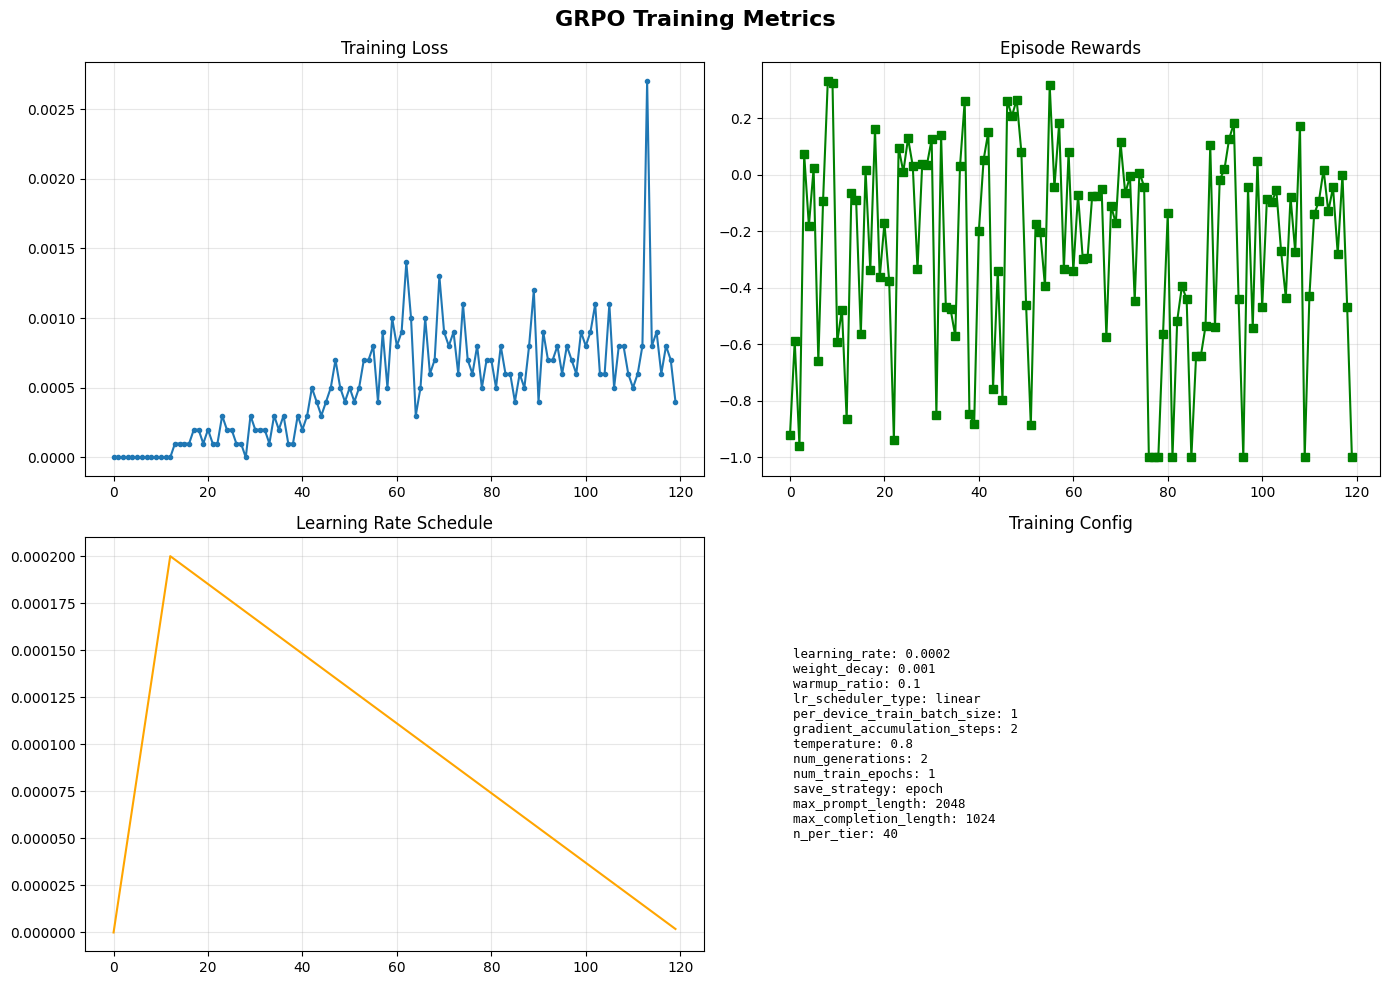

✅ Metrics updated.


In [23]:
import matplotlib.pyplot as plt
import json
import os
from pathlib import Path

# Load training logs
log_dir = Path("outputs_grpo_aegis/logs")
output_dir = Path("outputs_grpo_aegis")

def load_metrics():
    steps, losses, rewards, lrs = [], [], [], []

    # 1. Try to load from trainer state if available
    if 'trainer' in globals() and hasattr(trainer, "state"):
        for log_entry in trainer.state.log_history:
            if "step" in log_entry:
                steps.append(log_entry["step"])
                if "loss" in log_entry: losses.append(log_entry["loss"])
                if "reward" in log_entry: rewards.append(log_entry["reward"])
                if "learning_rate" in log_entry: lrs.append(log_entry["learning_rate"])

    # 2. If empty, try to load from trainer_state.json in output directory
    state_path = output_dir / "trainer_state.json"
    if not steps and state_path.exists():
        with open(state_path, 'r') as f:
            state = json.load(f)
            for log_entry in state.get("log_history", []):
                if "step" in log_entry:
                    steps.append(log_entry["step"])
                    if "loss" in log_entry: losses.append(log_entry["loss"])
                    if "reward" in log_entry: rewards.append(log_entry["reward"])
                    if "learning_rate" in log_entry: lrs.append(log_entry["learning_rate"])

    return steps, losses, rewards, lrs

steps, losses, rewards, learning_rates = load_metrics()

if steps:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("GRPO Training Metrics", fontsize=16, fontweight="bold")

    # Plot Training Loss
    ax = axes[0, 0]
    if losses:
        ax.plot(range(len(losses)), losses, marker=".", label="Loss")
        ax.set_title("Training Loss")
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, "Loss data not available", ha="center")

    # Plot Rewards
    ax = axes[0, 1]
    if rewards:
        ax.plot(range(len(rewards)), rewards, marker="s", color="green")
        ax.set_title("Episode Rewards")
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, "Reward data not available", ha="center")

    # Plot Learning Rate
    ax = axes[1, 0]
    if learning_rates:
        ax.plot(range(len(learning_rates)), learning_rates, color="orange")
        ax.set_title("Learning Rate Schedule")
        ax.grid(True, alpha=0.3)

    # Config Table
    ax = axes[1, 1]
    config_text = "\n".join([f"{k}: {v}" for k, v in TRAINING_CONFIG.items() if isinstance(v, (int, float, str))])
    ax.text(0.05, 0.5, config_text, verticalalignment='center', family='monospace', fontsize=9)
    ax.axis("off")
    ax.set_title("Training Config")

    plt.tight_layout()
    plt.savefig("outputs_grpo_aegis/training_metrics.png")
    plt.show()
    print("✅ Metrics updated.")
else:
    print("⚠️ No training logs found yet. Please wait until at least one logging step has passed.")

## 10. Save and Export Trained Model

Save the fine-tuned model checkpoint and export for inference.

In [25]:
output_dir = Path("outputs_grpo_aegis")
output_dir.mkdir(parents=True, exist_ok=True)

logger.info(f"💾 Saving fine-tuned model to {output_dir}...")

# Save model weights and config
model.save_pretrained(str(output_dir / "final_model"))
tokenizer.save_pretrained(str(output_dir / "final_model"))

logger.info("✅ Model saved successfully")

# Save training summary
summary = {
    "model_name": MODEL_NAME,
    "training_config": TRAINING_CONFIG,
    "dataset_config": DATASET_CONFIG,
    "total_samples": len(train_ds),
    "output_dir": str(output_dir),
    "model_path": str(output_dir / "final_model"),
}

summary_path = output_dir / "training_summary.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

logger.info(f"📋 Training summary saved to {summary_path}")

# Prepare inference example
logger.info("\n🎯 Model is ready for inference!")
logger.info(f"   Model path: {output_dir / 'final_model'}")
logger.info(f"   Tokenizer: {output_dir / 'final_model'}")
logger.info("\n📚 Usage example:")
logger.info(f"""
from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="{output_dir / 'final_model'}",
    load_in_4bit=True,
    max_seq_length=4096,
)

prompt = "Your prompt here"
inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
outputs = model.generate(**inputs, max_new_tokens=512)
response = tokenizer.decode(outputs[0])
""")

logger.info("\n" + "=" * 80)
logger.info("🎉 RL TRAINING PIPELINE COMPLETE!")
logger.info("=" * 80)
logger.info(f"Final model location: {output_dir / 'final_model'}")
logger.info(f"Training logs: {output_dir / 'logs'}")
logger.info(f"Checkpoints: {output_dir / 'checkpoint-*'}")
logger.info("=" * 80)

# Push to Hugging Face Hub
logger.info("\n🌐 Pushing model to Hugging Face Hub...")

# Extract model name for the repo naming
model_shortname = MODEL_NAME.split("/")[-1]
hf_repo_name = f"NishithP2004/aegis-{model_shortname}"

logger.info(f"📤 Target repo: {hf_repo_name}")

try:
    # Push model to hub
    model.push_to_hub(
        repo_id=hf_repo_name,
        token=os.environ.get("HF_TOKEN"),
        private=False,
        commit_message=f"GRPO fine-tuned model for AEGIS-Env - {TRAINING_CONFIG.get('num_train_epochs', 1)} epochs",
    )

    # Push tokenizer to hub
    tokenizer.push_to_hub(
        repo_id=hf_repo_name,
        token=os.environ.get("HF_TOKEN"),
        private=False,
    )

    logger.info(f"✅ Model successfully pushed to {hf_repo_name}")
    logger.info(f"🔗 URL: https://huggingface.co/{hf_repo_name}")

except Exception as e:
    logger.warning(f"⚠️  Failed to push to HF Hub: {e}")
    logger.info("   Make sure HF_TOKEN environment variable is set")
    logger.info("   You can set it with: !huggingface-cli login")

README.md:   0%|          | 0.00/570 [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   1%|1         |  556kB / 48.7MB            

Saved model to https://huggingface.co/NishithP2004/aegis-Llama-3.2-3B-Instruct-bnb-4bit


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mpi257_mah/tokenizer.json:  98%|#########8| 16.9MB / 17.2MB            

## Appendix: Quick Reference & Troubleshooting

### 🎯 Quick Hyperparameter Tuning

Adjust these in Section 3 to customize training:

- **Learning Rate**: Higher for faster learning, lower for stability (default: 2e-4)
- **Batch Size**: Increase for more stable gradients (default: 1 per device)
- **Temperature**: Controls generation diversity (default: 0.8)
- **Max Steps**: Total training iterations (default: 200)
- **LoRA Rank**: Higher rank = more parameters but slower (default: 8)

### 🐛 Common Issues

| Issue | Solution |
|-------|----------|
| CUDA Out of Memory | Reduce batch size, reduce max_seq_length, or use larger GPU instance |
| Dataset Building Fails | Check AEGIS_OPENENV_BASE URL is accessible from Colab |
| Slow Training | Enable mixed precision (already configured), use gradient accumulation |
| Import Errors | Restart kernel and re-run dependency installation cell |

### 📊 Expected Performance

With 120 samples (40 per tier) and 200 steps:
- Training time: ~8-12 hours on T4 GPU
- Final model size: ~3GB (4-bit quantized)
- Expected final reward: 0.5-0.7 range after convergence

### 🔗 Useful Links

- **GitHub Repo**: https://github.com/NishithP2004/aegis_env
- **HF Space**: https://huggingface.co/spaces/NishithP2004/aegis-env
- **Unsloth Docs**: https://github.com/unslothai/unsloth
- **TRL Docs**: https://huggingface.co/docs/trl/

### 💡 Next Steps

After training completes:
1. Download the model: `final_model/` directory
2. Push to Hugging Face Hub: `model.push_to_hub("your-hub-name")`
3. Evaluate on test set from AEGIS-Env
4. Fine-tune further with harder examples or different reward weights

## Optional: Inference & Evaluation

Test the trained model on AEGIS-Env (run after training completes).

In [27]:
# Load the fine-tuned model
logger.info("📥 Loading fine-tuned model for inference...")

final_model_path = "outputs_grpo_aegis/final_model"

model_infer, tokenizer_infer = FastLanguageModel.from_pretrained(
    model_name=final_model_path,
    load_in_4bit=True,
    max_seq_length=MAX_SEQ_LENGTH,
)

# Prepare model for inference
FastLanguageModel.for_inference(model_infer)

logger.info("✅ Model loaded for inference")

# Test inference on a sample
if len(train_ds) > 0:
    print("\n🧪 Running test inference on a training sample...")

    sample = train_ds[0]
    prompt_text = tokenizer_infer.apply_chat_template(
        sample["prompt"],
        tokenize=False,
        add_generation_prompt=True
    )

    # Generate response
    inputs = tokenizer_infer(prompt_text, return_tensors="pt").to("cuda")
    outputs = model_infer.generate(
        **inputs,
        temperature=0.7,
        max_new_tokens=512,
    )

    response = tokenizer_infer.decode(outputs[0], skip_special_tokens=True)

    print("\n💬 Model Raw Output:")
    print("-" * 80)
    # Extract just the response part (after the prompt)
    response_only = response.split("Assistant:\n")[-1].strip() if "Assistant:" in response else response
    print(response_only)
    print("-" * 80)

    # Try to parse as JSON
    try:
        parsed = _parse_action(_strip_markdown_json_fence(response_only), sample["mentor_max_score"])
        print(f"\n✅ Successfully parsed as AegisAction:")
        print(f"   - Proposed Score: {parsed.proposed_score}")
        print(f"   - Reasoning: {parsed.agent_reasoning}")
        print(f"   - Routing Decision: {parsed.routing_decision}")
    except Exception as e:
        print(f"\n⚠️ Failed to parse as JSON: {e}")

print("\n" + "=" * 80)
print("✨ Inference test complete!")
print("=" * 80)

==((====))==  Unsloth 2026.5.2: Fast Llama patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!

🧪 Running test inference on a training sample...

💬 Model Raw Output:
--------------------------------------------------------------------------------
system

Cutting Knowledge Date: December 2023
Today Date: 09 May 2026

user

You are **The Mentor**, the final agent who turns the validated assessment into a helpful report.

Goal: Produce clear, personalized, actionable feedback for the student.

Instructions:
- Synthesize the final score and reasoning from the pipeline history.
- Write encouraging, specific feedback: celebrate strengths, ident